# 數值分析作業 Problem 7：一維插值與繪圖

- 組員姓名、學號： 邱尹澤 C14111263、鍾秉勳 C14139017、侯品丞 C14096235、莊文泰 C14106153 

## 方法說明

1. **nearest interpolation**：取距離查詢位置最近的已知資料點。
2. **linear interpolation**：在每一對相鄰資料點之間使用直線。
3. **cubic interpolation**：每個區間使用三次多項式，並令兩端點的二階導數為 0，使曲線及其前兩階導數在節點處連續。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.0, 0.1, 0.15, 0.35, 0.6, 0.7, 0.95, 1.0])
y = np.array([1.0, 0.8187, 0.7408, 0.4966, 0.3012, 0.2466, 0.1496, 0.1353])
X = np.linspace(0.0, 1.0, 101)

# 題目要求的整合函式：依 option 選擇插值法並畫圖
def my_interp_plotter(x, y, X, option):
    if option == "nearest":
        Y = nearest_interpolation(x, y, X)
    elif option == "linear":
        Y = linear_interpolation(x, y, X)
    elif option in ("spline", "cubic"):
        Y = cubic_interpolation(x, y, X)
    else:
        raise ValueError("option must be 'nearest', 'linear', 'spline', or 'cubic'")

    title = "cubic" if option in ("spline", "cubic") else option
    plt.figure(figsize=(8, 5))
    plt.plot(X, Y, color="blue", label="interpolation")
    plt.plot(x, y, "ro", label="data points")
    plt.title(f"{title} interpolation of data")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()
    return Y

## nearest interpolation

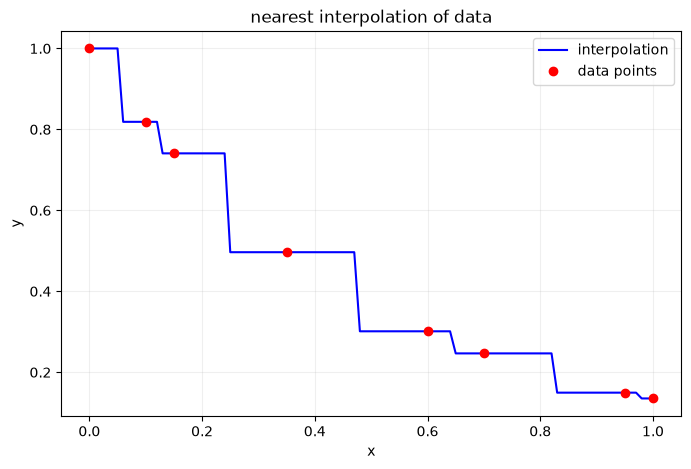

In [2]:
def nearest_interpolation(x, y, X):
    # 找出每個 X 右側的資料點索引
    right = np.searchsorted(x, X, side="left")
    right = np.clip(right, 0, len(x) - 1)
    left = np.clip(right - 1, 0, len(x) - 1)

    # 比較左右兩點的距離，距離相同時選左邊
    choose_right = np.abs(x[right] - X) < np.abs(X - x[left])
    nearest_index = np.where(choose_right, right, left)
    return y[nearest_index]

Y_nearest = my_interp_plotter(x, y, X, "nearest")

## linear interpolation

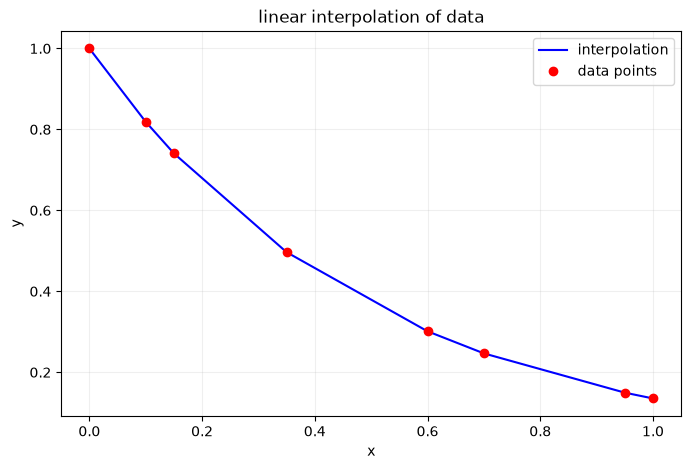

In [3]:
def linear_interpolation(x, y, X):
    # 找出每個 X 所在的相鄰資料區間 [x_i, x_(i+1)]
    interval = np.searchsorted(x, X, side="right") - 1
    interval = np.clip(interval, 0, len(x) - 2)

    x_left = x[interval]
    x_right = x[interval + 1]
    y_left = y[interval]
    y_right = y[interval + 1]

    # 線性插值公式：y_i + t(y_(i+1) - y_i)
    t = (X - x_left) / (x_right - x_left)
    return y_left + t * (y_right - y_left)

Y_linear = my_interp_plotter(x, y, X, "linear")

## cubic interpolation

題目文字使用 `spline`，範例圖片使用 `cubic`；本程式同時接受這兩個選項。

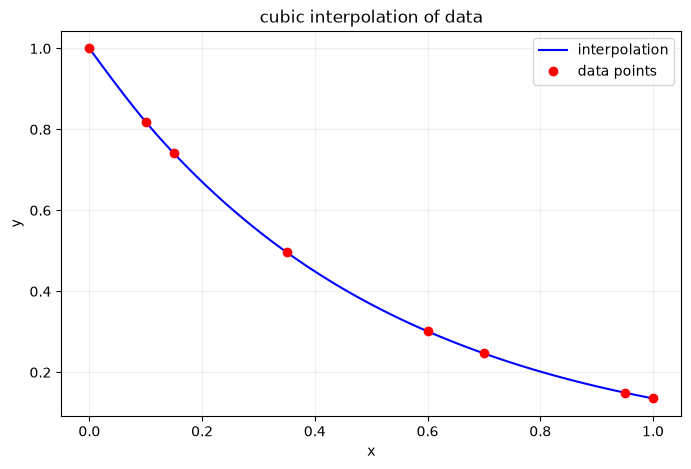

In [4]:
def cubic_interpolation(x, y, X):
    # Natural cubic spline：兩端點的二階導數設為 0
    n = len(x)
    h = np.diff(x)

    alpha = np.zeros(n)
    alpha[1:-1] = (
        3 * (y[2:] - y[1:-1]) / h[1:]
        - 3 * (y[1:-1] - y[:-2]) / h[:-1]
    )

    # Thomas algorithm：解三對角線性方程組
    lower = np.ones(n)
    upper_ratio = np.zeros(n)
    rhs = np.zeros(n)

    for i in range(1, n - 1):
        lower[i] = 2 * (x[i + 1] - x[i - 1]) - h[i - 1] * upper_ratio[i - 1]
        upper_ratio[i] = h[i] / lower[i]
        rhs[i] = (alpha[i] - h[i - 1] * rhs[i - 1]) / lower[i]

    a = y[:-1].copy()
    b = np.zeros(n - 1)
    c = np.zeros(n)
    d = np.zeros(n - 1)

    # 反向代入，求出每個區間的三次多項式係數
    for j in range(n - 2, -1, -1):
        c[j] = rhs[j] - upper_ratio[j] * c[j + 1]
        b[j] = (y[j + 1] - y[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])

    interval = np.searchsorted(x, X, side="right") - 1
    interval = np.clip(interval, 0, n - 2)
    dx = X - x[interval]

    return (
        a[interval]
        + b[interval] * dx
        + c[interval] * dx**2
        + d[interval] * dx**3
    )

Y_cubic = my_interp_plotter(x, y, X, "cubic")

## 結果討論

nearest interpolation 呈階梯狀；linear interpolation 由相鄰資料點之間的線段構成；cubic interpolation 則產生連續且較平滑的曲線。三種方法都通過原始資料點，但中間位置的估計方式不同。